# Benchmark

## 1. Environment

In [1]:
import cfe
import scanpy as sc
import pandas as pd

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[2025年07月02日 09时23分58秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

## 2. Data

In [2]:
# sample 500 cells from pancreas dataset in scvelo
fadata = cfe.data.read_pancrease(n_obs=500)
fadata

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
# add milestone network manually
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

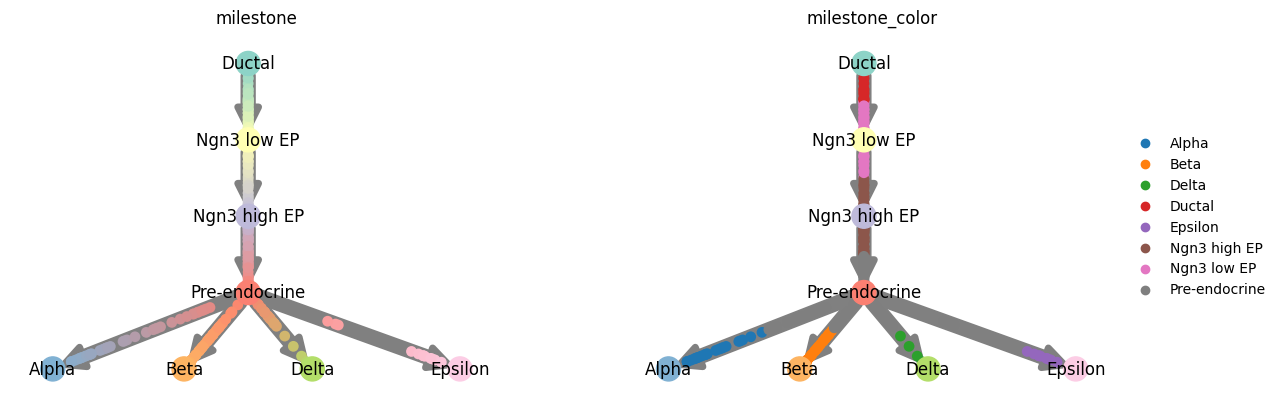

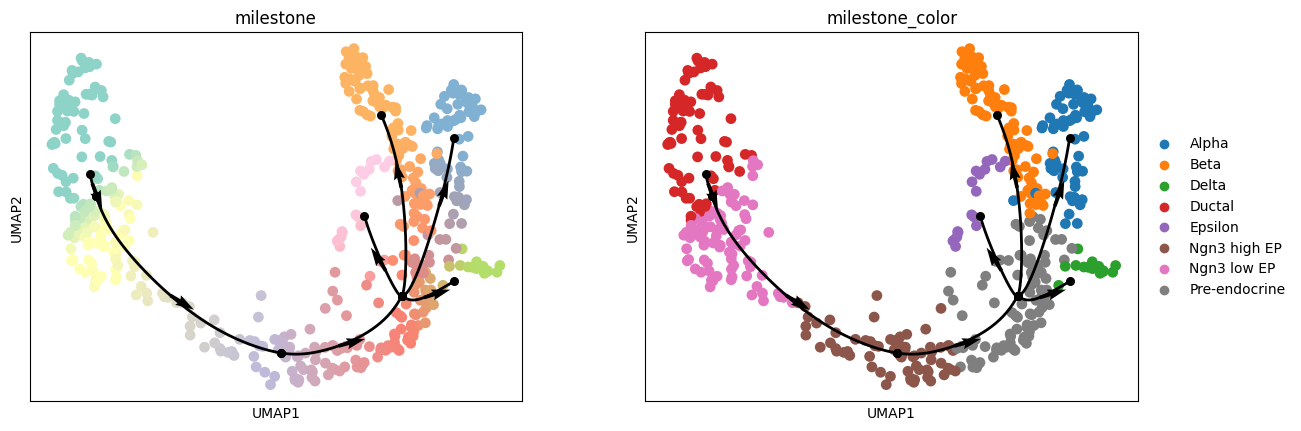

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)


## 3. Method

[2025年07月02日 09时24分04秒] INFO     Loaded function: <function cf_comp1 at 0x7f87f83b7b50> from                 
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_comp1.py                                                              
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7f87f84a9150>                                                                   
[2025年07月02日 09时24分05秒] INFO     Loaded function: <function cf_state_comp at 0x7f87f926fe20> from            
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_state_comp.py                                                         
                        INFO     method_backend: <cfe.method.fate_function_backend.F

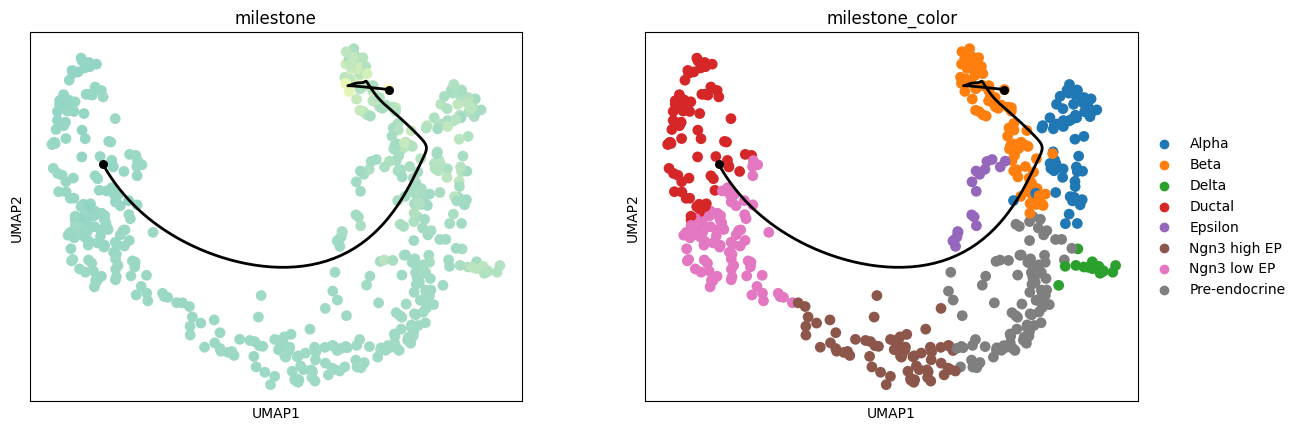

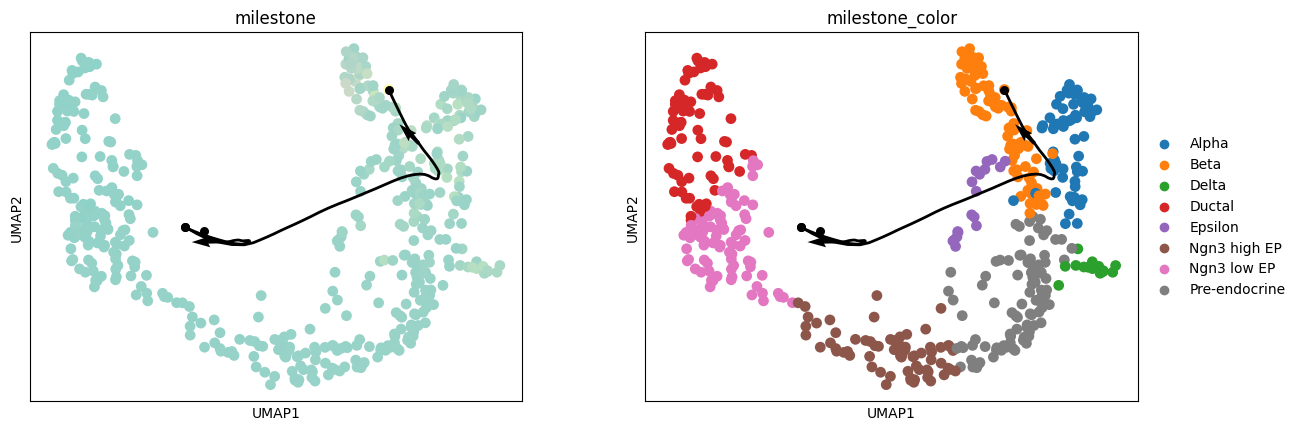

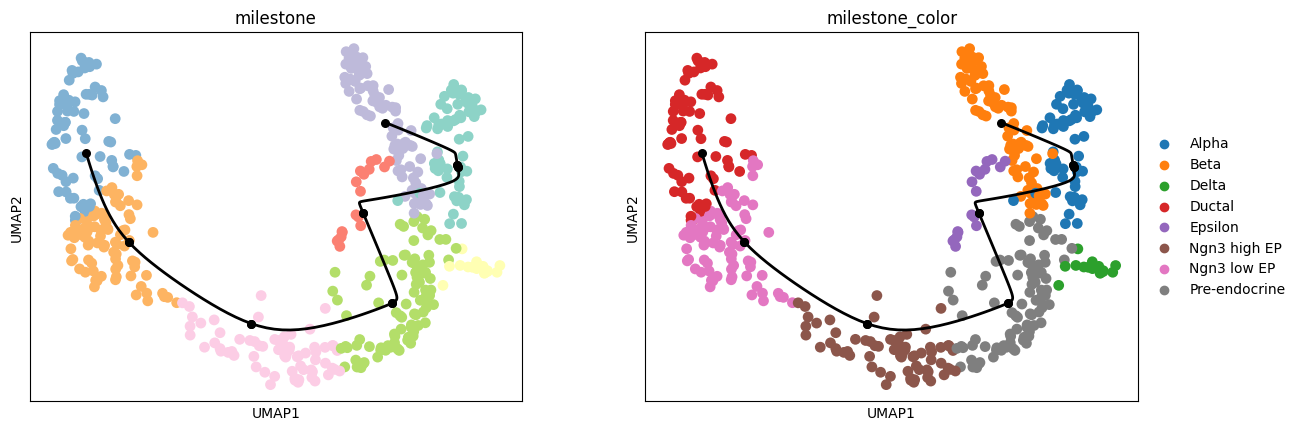

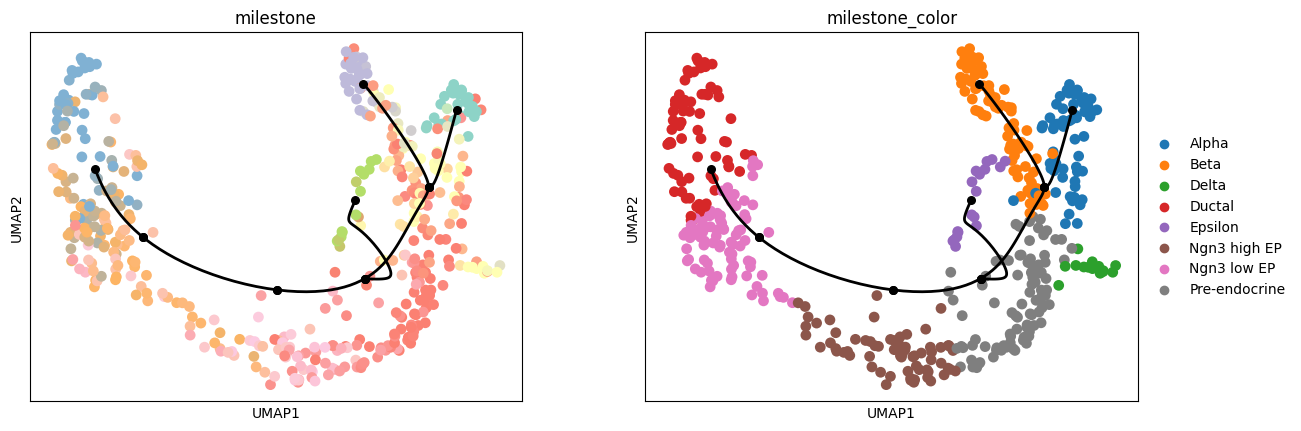

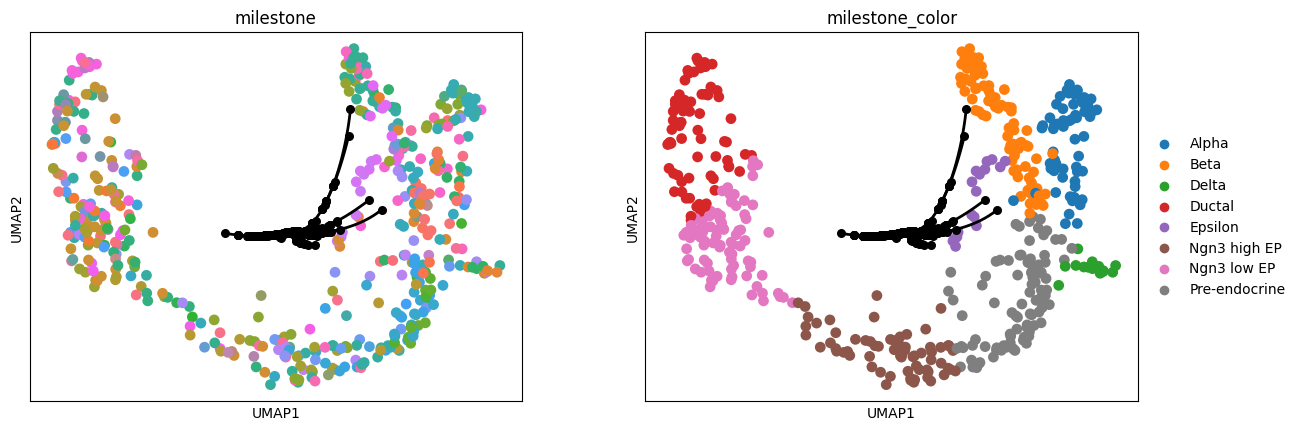

In [5]:
# TODO: PAGA need to be optimized, disconnected graph
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

# choose methods
#method_name_list = ["paga", "comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst", "scvelo"]
# TODO: angle will result in metric calculation error
# TODO: scvelo need apropriate velocity wrapper
method_name_list = ["comp1", "state_comp","cluster_mst","projection_mst","graph_mst"]

# execute methods
for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata)
    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)
        

Show model name

In [6]:
parsed_model_name_list = fadata.get_all_model_name() # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年07月02日 09时24分27秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'comp1-python_function',
  'state_comp-python_function',
  'cluster_mst-python_function',
  'projection_mst-python_function',
  'graph_mst-python_function'],
 ['ref',
  '20250702_092404__comp1-python_function__i8HFlNFBxM',
  '20250702_092405__state_comp-python_function__mnHc6H1N0x',
  '20250702_092407__cluster_mst-python_function__ktppUK6d4l',
  '20250702_092408__projection_mst-python_function__CyA1lrEann',
  '20250702_092409__graph_mst-python_function__5hBTb7LQoQ'])

## 4. Metric

Available metrics:

In [7]:
cfe.metric.metrics

,metric_id,plotmath,latex,html,long_name,category,type,perfect,worst,symmetric
0,correlation,cor[dist],\mathit{cor}_{\textrm{dist}},cor<sub>dist</sub>,Geodesic distance correlation,cell positions,specific,1,0.0,True
1,rf_mse,MSE[rf],\mathit{MSE}_{\textit{rf}},MSE<sub>rf</sub>,Random Forest MSE,neighbourhood,specific,0,0.3,False
2,rf_nmse,NMSE[rf],\mathit{NMSE}_{\textit{rf}},NMSE<sub>rf</sub>,Random Forest Normalised MSE,neighbourhood,specific,1,0.0,False
3,rf_rsq,R[rf]^2,R^{2}_{rf},R<sup>2</sup><sub>rf</sub>,Random Forest R²,neighbourhood,specific,1,0.0,False
4,lm_nmse,NMSE[lm],\mathit{NMSE}_{\textit{lm}},NMSE<sub>lm</sub>,Linear regression Normalised MSE,neighbourhood,specific,1,0.0,False
5,lm_mse,MSE[lm],\mathit{MSE}_{\textit{lm}},MSE<sub>lm</sub>,Linear regression MSE,neighbourhood,specific,0,0.3,False
6,lm_rsq,R[lm]^2,R^{2}_{lm},R<sup>2</sup><sub>lm</sub>,Linear regression R²,neighbourhood,specific,1,0.0,False
7,edge_flip,edgeflip,\textrm{edgeflip},edgeflip,Edge flip,topology,specific,1,0.0,True
8,him,HIM,\textrm{HIM},HIM,Hamming-Ipsen-Mikhailov similarity,topology,specific,1,0.0,True
9,isomorphic,isomorphic,\textrm{isomorphic},Isomorphic,isomorphic,topology,specific,1,0.0,True


Methods are chosen to be calculated

In [8]:
implemented = [
    "correlation",
    "rf_mse", "rf_rsq", "rf_nmse",
    "lm_mse", "lm_rsq", "lm_nmse",
    "edge_flip", "him",
    # feature importance need to be fixed
    # "featureimp_cor", "featureimp_wcor",
    # "featureimp_ks", "featureimp_wilcox",
    "F1_branches", "F1_milestones"
]
implemented

['correlation',
 'rf_mse',
 'rf_rsq',
 'rf_nmse',
 'lm_mse',
 'lm_rsq',
 'lm_nmse',
 'edge_flip',
 'him',
 'F1_branches',
 'F1_milestones']

Metric calculation

In [9]:
models = list(fadata.uns["cfe"]["trajectory_history_dict"].keys())
# 4. 确保每个模型都有 waypoint_wrapper
for m in set(models) | {"ref"}:
    fadata.model_name = m
    if not fadata.is_wrapped_with_waypoints:
        fadata.add_waypoints()
# 4. 针对每个方法，调用 calculate_metrics 并收集结果
records = {}
for model in models:
    # 跳过参考自身（ref vs ref）若不想算，可以加 if model=="ref": continue
    print(f"Calculating metrics for model: {model}")
    res = cfe.metric.calculate_metrics(
        fadata,
        now_model=model,
        ref_model="ref",
        simplify=False,  # 是否简化结果
        metrics=implemented
    )
    # 把可能缺失的指标填成 NaN
    for m in implemented:
        res.setdefault(m, float("nan"))
    records[model] = res

# 5. 构造成 DataFrame
df = pd.DataFrame.from_dict(records, orient="index", columns=implemented)

# 6. （可选）把行索引改成更可读的名字，或保存到文件
df.index.name = "method"
df

Calculating metrics for model: ref
Calculating metrics for model: 20250702_092404__comp1-python_function__i8HFlNFBxM
Calculating metrics for model: 20250702_092405__state_comp-python_function__mnHc6H1N0x
Calculating metrics for model: 20250702_092407__cluster_mst-python_function__ktppUK6d4l
Calculating metrics for model: 20250702_092408__projection_mst-python_function__CyA1lrEann
Calculating metrics for model: 20250702_092409__graph_mst-python_function__5hBTb7LQoQ


,correlation,rf_mse,rf_rsq,rf_nmse,lm_mse,lm_rsq,lm_nmse,edge_flip,him,F1_branches,F1_milestones
method,,,,,,,,,,,
ref,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
20250702_092404__comp1-python_function__i8HFlNFBxM,0.197914,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.250013,NaN,NaN
20250702_092405__state_comp-python_function__mnHc6H1N0x,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.285714,0.191442,NaN,NaN
20250702_092407__cluster_mst-python_function__ktppUK6d4l,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.374486,NaN,NaN
20250702_092408__projection_mst-python_function__CyA1lrEann,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.666667,0.263755,NaN,NaN
20250702_092409__graph_mst-python_function__5hBTb7LQoQ,0.022460,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
